# So sánh tổng hợp các model — House Prices

Notebook này **không train lại**. Chỉ đọc kết quả đã lưu trong:

```
experiments/
├── xgboost/<timestamp>/metrics.json
├── decision_tree/<timestamp>/metrics.json
└── random_forest/<timestamp>/metrics.json
```

Lấy lần chạy có **RMSE thấp nhất** của mỗi model để so sánh.

## 0. Google Colab — gắn Drive

In [3]:
import os
from pathlib import Path

IN_COLAB = False
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    if Path("/content/drive/MyDrive").exists():
        print("Drive đã gắn sẵn")
    else:
        drive.mount("/content/drive")
    WORK_DIR = Path("/content/drive/MyDrive/Lab02_HousePrice ")
    os.chdir(WORK_DIR)
    print("Đang làm việc tại:", os.getcwd())
else:
    print("Local:", os.getcwd())

Drive đã gắn sẵn
Đang làm việc tại: /content/drive/MyDrive/Lab02_HousePrice 


## 1. Import

In [4]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Đọc kết quả từ experiments/

Nếu thiếu folder nào, bảng sẽ báo `chưa có`. Chạy xong notebook model đó rồi chạy lại cell này.

In [5]:
MODEL_DIRS = {
    "XGBoost": Path("experiments") / "xgboost",
    "Decision Tree": Path("experiments") / "decision_tree",
    "Random Forest": Path("experiments") / "random_forest",
}

rows = []
all_runs = []

for model_name, exp_dir in MODEL_DIRS.items():
    if not exp_dir.exists():
        rows.append({
            "model": model_name,
            "best_cv_rmse": np.nan,
            "baseline_cv_rmse": np.nan,
            "improvement": np.nan,
            "n_runs": 0,
            "best_folder": "chưa có",
            "status": "chưa chạy",
        })
        continue

    runs = []
    for folder in sorted(exp_dir.iterdir()):
        mf = folder / "metrics.json"
        cf = folder / "config.json"
        if not (folder.is_dir() and mf.exists()):
            continue
        with open(mf, encoding="utf-8") as f:
            m = json.load(f)
        params = {}
        if cf.exists():
            with open(cf, encoding="utf-8") as f:
                params = json.load(f).get("best_params", {})
        rmse = m.get("best_cv_rmse")
        rec = {
            "model": model_name,
            "folder": folder.name,
            "best_cv_rmse": rmse,
            "baseline_cv_rmse": m.get("baseline_cv_rmse"),
            "improvement": m.get("improvement"),
            "best_params": params,
        }
        runs.append(rec)
        all_runs.append(rec)

    if not runs:
        rows.append({
            "model": model_name,
            "best_cv_rmse": np.nan,
            "baseline_cv_rmse": np.nan,
            "improvement": np.nan,
            "n_runs": 0,
            "best_folder": "không có metrics.json",
            "status": "thiếu file",
        })
        continue

    best = min(runs, key=lambda r: r["best_cv_rmse"] if r["best_cv_rmse"] is not None else 1e18)
    rows.append({
        "model": model_name,
        "best_cv_rmse": best["best_cv_rmse"],
        "baseline_cv_rmse": best["baseline_cv_rmse"],
        "improvement": best["improvement"],
        "n_runs": len(runs),
        "best_folder": best["folder"],
        "best_params": best["best_params"],
        "status": "OK",
    })

summary = pd.DataFrame(rows)
runs_df = pd.DataFrame(all_runs)

print("=== TẤT CẢ LẦN CHẠY ===")
if runs_df.empty:
    print("Chưa đọc được lần chạy nào. Kiểm tra folder experiments/ trên Drive.")
else:
    display(runs_df[["model", "folder", "best_cv_rmse", "baseline_cv_rmse"]] if "display" in dir()
            else print(runs_df.to_string(index=False)))

print("\n=== MODEL TỐT NHẤT CỦA TỪNG LOẠI ===")
display(summary[["model", "best_cv_rmse", "baseline_cv_rmse", "improvement", "n_runs", "best_folder", "status"]])

=== TẤT CẢ LẦN CHẠY ===
        model          folder  best_cv_rmse  baseline_cv_rmse  improvement                                                                                                                                                                      best_params
      XGBoost 20260920_103629  26905.644553               NaN          NaN                                                   {'subsample': 0.9, 'n_estimators': 500, 'min_child_weight': 4, 'max_depth': 2, 'learning_rate': 0.15, 'colsample_bytree': 1.0}
      XGBoost 20260920_105040  25970.459280               NaN          NaN {'subsample': 0.95, 'reg_lambda': 2.5, 'reg_alpha': 2, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.5}
      XGBoost 20260920_144539  25970.459280               NaN          NaN {'subsample': 0.95, 'reg_lambda': 2.5, 'reg_alpha': 2, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.05, 'gamma'

None


=== MODEL TỐT NHẤT CỦA TỪNG LOẠI ===


,model,best_cv_rmse,baseline_cv_rmse,improvement,n_runs,best_folder,status
0,XGBoost,25970.459280,NaN,NaN,3,20260920_105040,OK
1,Decision Tree,37491.760648,38902.036414,1410.275765,3,20260920_235559,OK
2,Random Forest,29072.292686,30140.043251,1067.750565,3,20260921_082756,OK


## 3. Bảng xếp hạng

In [6]:
rank = summary.dropna(subset=["best_cv_rmse"]).sort_values("best_cv_rmse").copy()
if rank.empty:
    raise SystemExit("Chưa có RMSE nào để xếp hạng. Hãy chạy xong các notebook model trước.")

rank["hạng"] = range(1, len(rank) + 1)
rank["rmse_vs_nhất"] = rank["best_cv_rmse"] - rank["best_cv_rmse"].min()
print("RMSE càng thấp càng tốt")
display(rank[["hạng", "model", "best_cv_rmse", "rmse_vs_nhất", "best_folder"]])

winner = rank.iloc[0]
print(f"\n→ Model tốt nhất: {winner['model']}  |  RMSE = {winner['best_cv_rmse']:.2f}")
print(f"  Folder: experiments/.../{winner['best_folder']}")
print(f"  File nộp: experiments/<tên_model>/{winner['best_folder']}/predictions.csv")

RMSE càng thấp càng tốt


,hạng,model,best_cv_rmse,rmse_vs_nhất,best_folder
0,1,XGBoost,25970.459280,0.000000,20260920_105040
2,2,Random Forest,29072.292686,3101.833406,20260921_082756
1,3,Decision Tree,37491.760648,11521.301369,20260920_235559



→ Model tốt nhất: XGBoost  |  RMSE = 25970.46
  Folder: experiments/.../20260920_105040
  File nộp: experiments/<tên_model>/20260920_105040/predictions.csv


## 4. Biểu đồ so sánh RMSE

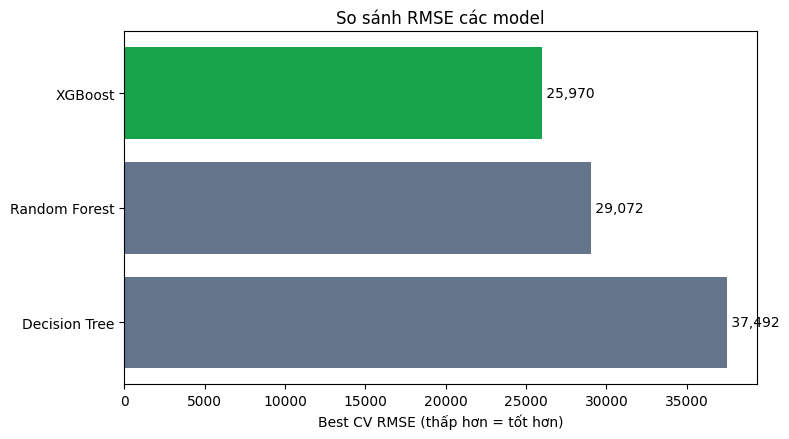

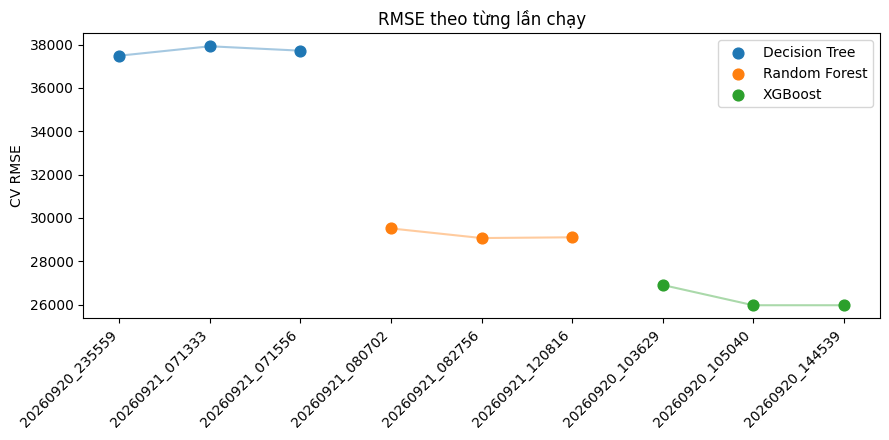

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = rank.sort_values("best_cv_rmse", ascending=False)
colors = ["#16a34a" if m == winner["model"] else "#64748b" for m in plot_df["model"]]
bars = ax.barh(plot_df["model"], plot_df["best_cv_rmse"], color=colors)
ax.set_xlabel("Best CV RMSE (thấp hơn = tốt hơn)")
ax.set_title("So sánh RMSE các model")
for bar, val in zip(bars, plot_df["best_cv_rmse"]):
    ax.text(val, bar.get_y() + bar.get_height() / 2, f" {val:,.0f}", va="center")
plt.tight_layout()
plt.show()

if not runs_df.empty:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for model, g in runs_df.groupby("model"):
        ax.scatter(g["folder"], g["best_cv_rmse"], label=model, s=60)
        ax.plot(g["folder"], g["best_cv_rmse"], alpha=0.4)
    ax.set_ylabel("CV RMSE")
    ax.set_title("RMSE theo từng lần chạy")
    ax.legend()
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 5. Best params từng model

In [8]:
for _, r in summary.iterrows():
    print("=" * 60)
    print(r["model"], "|", r["status"], "| folder:", r["best_folder"])
    if r["status"] == "OK":
        print("RMSE:", r["best_cv_rmse"])
        print("Params:")
        for k, v in (r.get("best_params") or {}).items():
            print(f"  {k}: {v}")
    print()

XGBoost | OK | folder: 20260920_105040
RMSE: 25970.459279727806
Params:
  subsample: 0.95
  reg_lambda: 2.5
  reg_alpha: 2
  n_estimators: 400
  min_child_weight: 1
  max_depth: 4
  learning_rate: 0.05
  gamma: 0.1
  colsample_bytree: 0.5

Decision Tree | OK | folder: 20260920_235559
RMSE: 37491.76064824978
Params:
  min_samples_split: 20
  min_samples_leaf: 10
  max_features: 0.8
  max_depth: 8
  criterion: absolute_error

Random Forest | OK | folder: 20260921_082756
RMSE: 29072.292685679695
Params:
  n_estimators: 400
  min_samples_split: 8
  min_samples_leaf: 1
  max_features: 0.5
  max_depth: 15



## 6. Nhận xét (mẫu — chỉnh lại cho đúng số liệu khi chạy)

* XGBoost đứng đầu vì boosting học dần phần residual, kết hợp learning_rate=0.05, max_depth=4, n_estimators=400 và regularization (reg_alpha, reg_lambda, gamma) nên vừa đủ phức tạp, ít overfit hơn 1 cây.

* Random Forest đứng giữa: 400 cây, max_depth=15, max_features=0.5 ổn định hơn Decision Tree nhưng không sửa lỗi tuần tự như boosting nên RMSE cao hơn XGBoost.

* Decision Tree kém nhất: chỉ 1 cây, max_depth=8 + min_samples_leaf=10 để đỡ overfit thì bias tăng, RMSE cao rõ.

## 7. Lưu bảng so sánh lên Drive

In [9]:
out_dir = Path("experiments") / "comparison"
out_dir.mkdir(parents=True, exist_ok=True)

summary.to_csv(out_dir / "summary_best_per_model.csv", index=False)
if not runs_df.empty:
    runs_df.to_csv(out_dir / "all_runs.csv", index=False)
rank.to_csv(out_dir / "ranking.csv", index=False)

print("Đã lưu:")
print(" ", (out_dir / "summary_best_per_model.csv").resolve())
print(" ", (out_dir / "ranking.csv").resolve())

Đã lưu:
  /content/drive/MyDrive/Lab02_HousePrice /experiments/comparison/summary_best_per_model.csv
  /content/drive/MyDrive/Lab02_HousePrice /experiments/comparison/ranking.csv
